# HISTOGRAMS

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
from matplotlib import font_manager
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D

In [2]:
plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

h_times = {
    r'G = 0.05, $\sigma_e$ = 0.05': [2000,3000, 4000, 5000],
    r'G = 0.05, $\sigma_e$ = 0.40': [1, 200, 400, 5000],
    r'G = 0.30, $\sigma_e$ = 0.05': [1, 5, 1600, 5000],
    r'G = 0.30, $\sigma_e$ = 0.40': [1, 100, 1000, 5000],
}

In [3]:
path_teorico = "DATA/binomial.dat"

if os.path.exists(path_teorico):
    data_theo = np.loadtxt(path_teorico)
    x_theo, y_theo = data_theo[:, 0], data_theo[:, 1]
else:
    print(f"Aviso: Arquivo {path_teorico} não encontrado. Curva teórica não será plotada.")
    x_theo, y_theo = None, None

def plot_kde_evolution(label_key, mode, base_path, h_times):
    times = h_times[label_key]
    
    if mode == 'homo':
        y_limit, y_step, red_lines = 40, 5, [0.5]
    else:
        y_limit, y_step, red_lines = 20, 5, [0.4, 0.6]

    colors = ['#D3D3D3', '#969696', '#525252', '#000000']
    ls = [':', '-.', '--', '-']

    fig, ax = plt.subplots(figsize=(12, 4))
    
    for i, t in enumerate(times):
        file = os.path.join(base_path, f"data{t}.dat")
        try:
            df = pd.read_csv(file, sep='\s+', header=None, 
                             names=['id','x','y','sp','deg','phenotype','fit'])
            pheno = df['phenotype'].dropna().values
            kde = gaussian_kde(pheno)
            x_range = np.linspace(0.25, 0.75, 500)
            ax.plot(x_range, kde(x_range), color=colors[i], linestyle=ls[i], lw=3, 
                    label=fr'$\mathsf{{t = {t}}}$', zorder=10-i)
        except Exception as e:
            print(f"Erro ao ler {file}: {e}")
            continue

    if x_theo is not None:
        ax.plot(x_theo, y_theo, color='#1f77b4', linestyle='-', lw=2.5, 
                label=r'$\mathsf{Theoretical}$', zorder=5)

    for p in red_lines: 
        ax.axvline(p, color='red', lw=2, alpha=0.4, zorder=1)

    ax.set_xlim(0.25, 0.75)
    ax.set_ylim(0, y_limit)
    ax.set_xlabel(r'$\mathsf{P}$', fontsize=40)
    ax.set_ylabel(r'$\mathsf{d(P)}$', fontsize=40)
    
    ax.set_yticks(np.arange(0, y_limit + 0.1, y_step))
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.2f}$'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.1f}$'))
    
    ax.tick_params(axis='both', which='major', length=12, width=2, labelsize=36, 
                   direction='in', top=False, right=False)
    ax.tick_params(axis='both', which='minor', length=6, width=1.5, direction='in')
    
    ax.legend(fontsize=18, loc="upper right", frameon=False)
    
    plt.savefig(f'KDE_{mode}_{label_key}.pdf', bbox_inches='tight')
    plt.show()

def plot_spatial_snapshots(label_key, mode, base_path, h_times):
    times = h_times[label_key]
    cmap_sp = plt.get_cmap('Set1')
    
    n = len(times)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 6 * nrows), facecolor='white')
    
    if n > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for i, t in enumerate(times):
        ax = axes[i]
        file = os.path.join(base_path, f"data{t}.dat")
        try:
            df = pd.read_csv(file, sep='\s+', header=None, 
                             names=['id', 'x', 'y', 'species', 'deg', 'pheno', 'fit'])
            
            if df.empty: continue

            sizes = (((df['pheno'] - 0.4) / 0.2) * 10 + 5) * 5
            colors = [cmap_sp(int(s) % cmap_sp.N) for s in df['species']]
            
            ax.scatter(df['x'], df['y'], color=colors, s=sizes, alpha=0.8)
            
            ax.set_xlim(0, 101)
            ax.set_ylim(0, 101)
            ax.set_aspect('equal')
            
            ax.set_xticks([0, 50, 100])
            ax.set_yticks([0, 50, 100])
            
            ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%g}$'))
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%g}$'))
            
            ax.tick_params(axis='both', which='major', labelsize=18, direction='in', 
                           length=10, width=2, top=True, right=True)
            ax.tick_params(axis='both', which='minor', direction='in', 
                           length=5, width=1.5, top=True, right=True)
            
            ax.axvline(x=50, color='gray', linewidth=2, alpha=0.3)
            ax.set_facecolor('white')
            
            ax.text(5, 92, fr'$\mathsf{{t = {t}}}$', fontsize=20, 
                    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

        except Exception as e:
            print(f"Erro ao processar {file}: {e}")

    for j in range(len(times), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(f'Spatial_{mode}_{label_key}.pdf', bbox_inches='tight')
    plt.show()


In [4]:
#---Directories---
config_dirs = {
    r'G = 0.05, $\sigma_e$ = 0.05': {
        'homo': 'DATA/homogeneous/G5sigma5/All/',
        'hetero': 'DATA/heterogeneous/G5sigma5/All/'
    },
    r'G = 0.05, $\sigma_e$ = 0.40': {
        'homo': 'DATA/homogeneous/G5sigma40/All/',
        'hetero': 'DATA/heterogeneous/G5sigma40/All/'
    },
    r'G = 0.30, $\sigma_e$ = 0.05': {
        'homo': 'DATA/homogeneous/G30sigma5/All/',
        'hetero': 'DATA/heterogeneous/G30sigma5/All/'
    },
    r'G = 0.30, $\sigma_e$ = 0.40': {
        'homo': 'DATA/homogeneous/G30sigma40/All/',
        'hetero': 'DATA/heterogeneous/G30sigma40/All/'
    }
}
##code/DATA/sigma30/heterogeneous/G5/All/
##code/DATA/G=B/heterogeneous/sigma5/All/

In [5]:
#Choose a cenary and mode that you wish
cenary = r'G = 0.05, $\sigma_e$ = 0.05' 
mode = 'hetero'                         

path_target = config_dirs[cenary][mode]


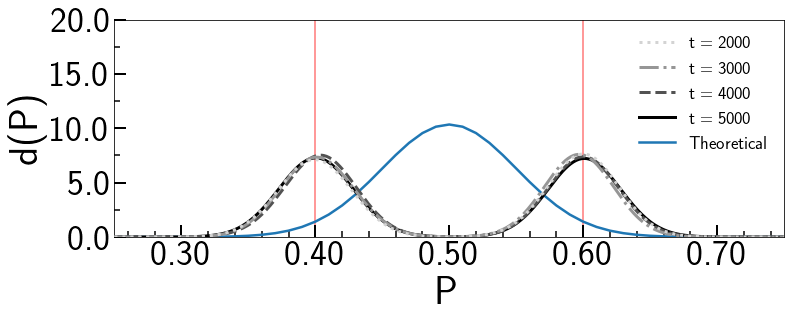

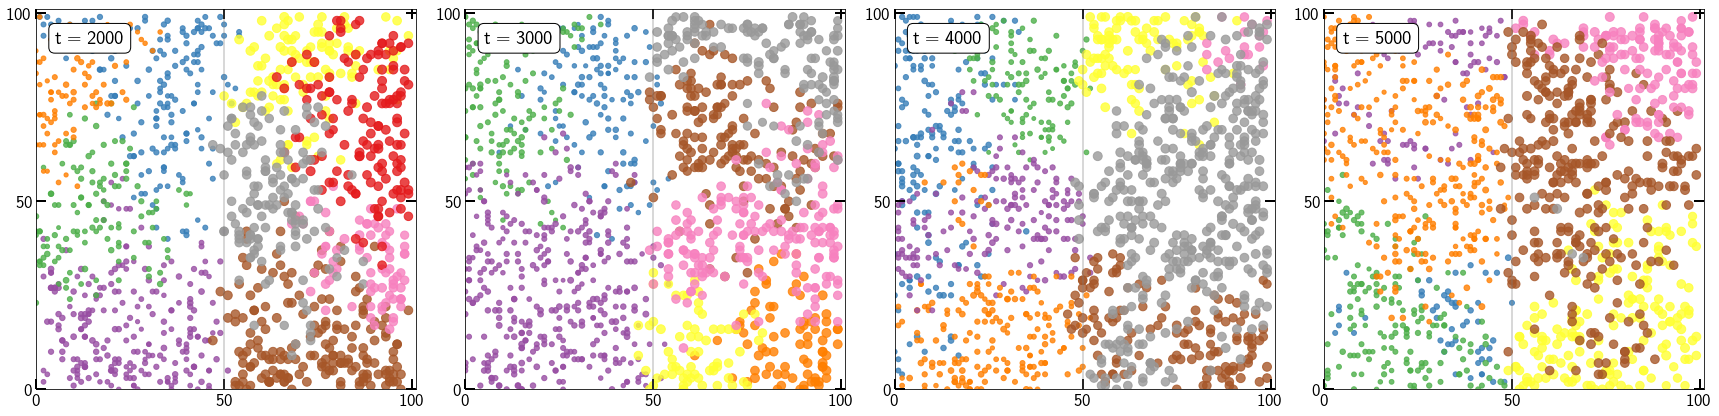

In [6]:
plot_kde_evolution(label_key=cenary, mode=mode, base_path=path_target, h_times=h_times)
plot_spatial_snapshots(label_key=cenary, mode=mode, base_path=path_target, h_times=h_times)

# VIOLIN PLOTS

In [7]:

def plot_violin_comparison(mode='hetero'):
    target_t = 5000 
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 20), facecolor='white')
    
    ref_lines = [0.5] if mode == 'homo' else [0.4, 0.6]
    
    row_letters = ['a', 'b', 'c', 'd']
    

    for idx, (label, paths) in enumerate(config_dirs.items()):
        ax = axes[idx]
        file_path = os.path.join(paths[mode], f"data{target_t}.dat")
        
        if not os.path.exists(file_path):
            print(f"Arquivo não encontrado: {file_path}")
            continue
        
        df = pd.read_csv(file_path, sep='\s+', header=None, 
                         names=['id','x','y','species','deg','phenotype','fit'])
        
     
        sns.violinplot(data=df, x='species', y='phenotype', ax=ax, 
                       color='#808080', inner="quartile", linewidth=1.8, 
                       cut=0, bw_adjust=0.5, density_norm="width")
        
        for line in ref_lines: 
            ax.axhline(y=line, color='red', ls='--', alpha=0.6, lw=2.0, zorder=0)
        
        ax.text(0.02, 0.90, fr'\textbf{{{row_letters[idx]}}}', transform=ax.transAxes, 
                fontsize=30, fontweight='bold', va='top')

        clean_label = label.replace('$', '')
        ax.text(0.08, 0.90, fr'$\mathsf{{{clean_label}}}$', transform=ax.transAxes, 
                fontsize=22, va='top', bbox=dict(facecolor='white', alpha=1.0, edgecolor='none'))

        ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, 
                       length=12, width=2, labelsize=22)
        
        if "0.40" in label:
            ax.set_ylim(0.2, 0.8) 
        else:
            ax.set_ylim(0.35, 0.65) 

        ax.set_ylabel(r'$\mathsf{P}$', fontsize=30)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.1f}$'))
        ax.set_xlabel('')
    axes[3].set_xlabel(r'$\mathsf{Species \ ID}$', fontsize=30)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2)
    
    plt.savefig(f'Violins_{mode}.pdf', dpi=300, bbox_inches='tight')
    plt.show()



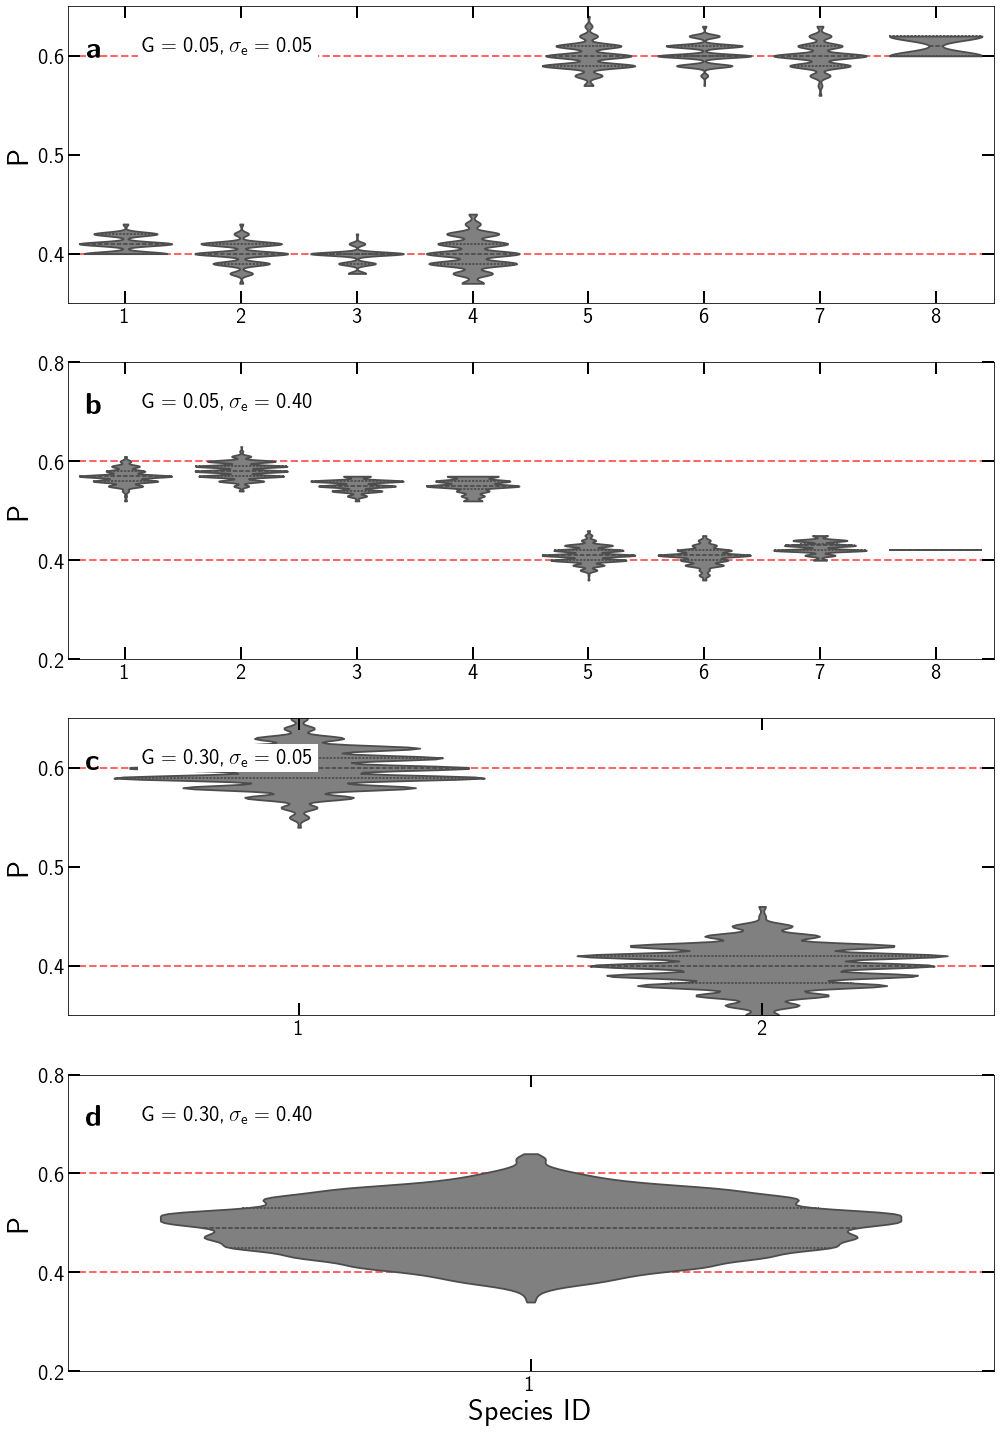

In [8]:
mode_choice = 'hetero'

plot_violin_comparison(mode=mode_choice)

# EVOLUTION OF PHENOTYPIC DISTRIBUTION

In [9]:
plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

def calculate_manual_profile(data, x_range, h=0.015):
    n = len(data)
    final_curve = np.zeros_like(x_range)
    for point in data:
        z = (x_range - point) / h
        gaussian = (1.0 / (h * np.sqrt(2 * np.pi))) * np.exp(-0.5 * z**2)
        final_curve += gaussian
    return final_curve / n

def generate_evolution_plot(base_directory):
    timepoints = [1, 10, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
    ncols, nrows = 5, 3
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(42, 32))
    axes_flat = axes.flatten()
    cmap = plt.get_cmap('turbo')
    
    TITLE_SIZE = 70
    AXIS_LABEL_SIZE = 65
    TICK_SIZE = 60
    LEGEND_SIZE = 85

    p_min, p_max = 0.3, 0.7
    global_y_limit = 300 
    bin_width = (p_max - p_min) / 30

    for i, t in enumerate(timepoints):
        ax = axes_flat[i]
        file_path = os.path.join(base_directory, f"data{t}.dat")
        
        if os.path.exists(file_path):
            try:
                df = pd.read_csv(file_path, delim_whitespace=True, header=None,
                                 names=['id', 'x', 'y', 'species', 'deg', 'phenotype', 'fit'])
                
                species_list = df['species'].unique()
                data_per_species = [df[df['species'] == s]['phenotype'] for s in species_list]
                colors = [cmap(val) for val in np.linspace(0, 1, len(species_list))]
                
                ax.hist(data_per_species, bins=30, range=(p_min, p_max), stacked=True, 
                        color=colors, edgecolor='none', alpha=0.8, zorder=2)

                phenotypes = df['phenotype'].values
                if len(phenotypes) > 1:
                    x_range = np.linspace(p_min, p_max, 250)
                    y_final = calculate_manual_profile(phenotypes, x_range, h=0.015) * len(phenotypes) * bin_width
                    ax.plot(x_range, y_final, color='black', linewidth=8, zorder=10)
                    
                    for p_val, c in zip([0.4, 0.6], ['#0000FF', '#FF0000']):
                        idx = (np.abs(x_range - p_val)).argmin()
                        ax.plot(p_val, y_final[idx], 'o', color=c, markersize=26, 
                                markeredgecolor='black', markeredgewidth=5, zorder=11)
            except Exception as e:
                print(f"Error processing time {t}: {e}")

        ax.set_title(rf"$\mathsf{{t = {t}}}$", fontsize=TITLE_SIZE, pad=45)
        
        ax.set_xticks([0.4, 0.5, 0.6])
        ax.set_xticklabels([r'$\mathsf{0.4}$', r'$\mathsf{0.5}$', r'$\mathsf{0.6}$'], fontsize=TICK_SIZE)
        ax.set_xlabel(r'$\mathsf{P}$', fontsize=AXIS_LABEL_SIZE, labelpad=25)

        ax.set_yticks([0, 150, 300])
        if i % ncols == 0:
            ax.set_yticklabels([r'$\mathsf{0}$', r'$\mathsf{150}$', r'$\mathsf{300}$'], fontsize=TICK_SIZE)
            ax.set_ylabel(r'$\mathsf{Abundance}$', fontsize=AXIS_LABEL_SIZE, labelpad=35)
        else:
            ax.set_yticklabels([])

        ax.axvline(0.5, color='black', ls='--', lw=6, alpha=0.4, zorder=1)
        ax.tick_params(axis='both', which='major', direction='in', width=5, length=20, pad=20)
        
        ax.set_xlim(p_min, p_max)
        ax.set_ylim(0, global_y_limit)
        for spine in ax.spines.values(): spine.set_linewidth(5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=r'$\mathsf{P = 0.4}$',
               markerfacecolor='#0000FF', markersize=45, markeredgecolor='black', markeredgewidth=5),
        Line2D([0], [0], color='black', linestyle='--', linewidth=8, alpha=0.5, label=r'$\mathsf{P = 0.5}$'),
        Line2D([0], [0], marker='o', color='w', label=r'$\mathsf{P = 0.6}$',
               markerfacecolor='#FF0000', markersize=45, markeredgecolor='black', markeredgewidth=5)
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
               fontsize=LEGEND_SIZE, frameon=False, bbox_to_anchor=(0.5, -0.05))

    plt.subplots_adjust(
        left=0.08, 
        right=0.97, 
        bottom=0.08, 
        top=0.92, 
        hspace=0.6, 
        wspace=0.3
    )
    
    plt.savefig("phenotype_evolution_grid.pdf", dpi=300, bbox_inches='tight')
    plt.show()


/tmp/ipykernel_182447/2809018367.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None,
/tmp/ipykernel_182447/2809018367.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None,
/tmp/ipykernel_182447/2809018367.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None,
/tmp/ipykernel_182447/2809018367.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None,
/tmp/ipy

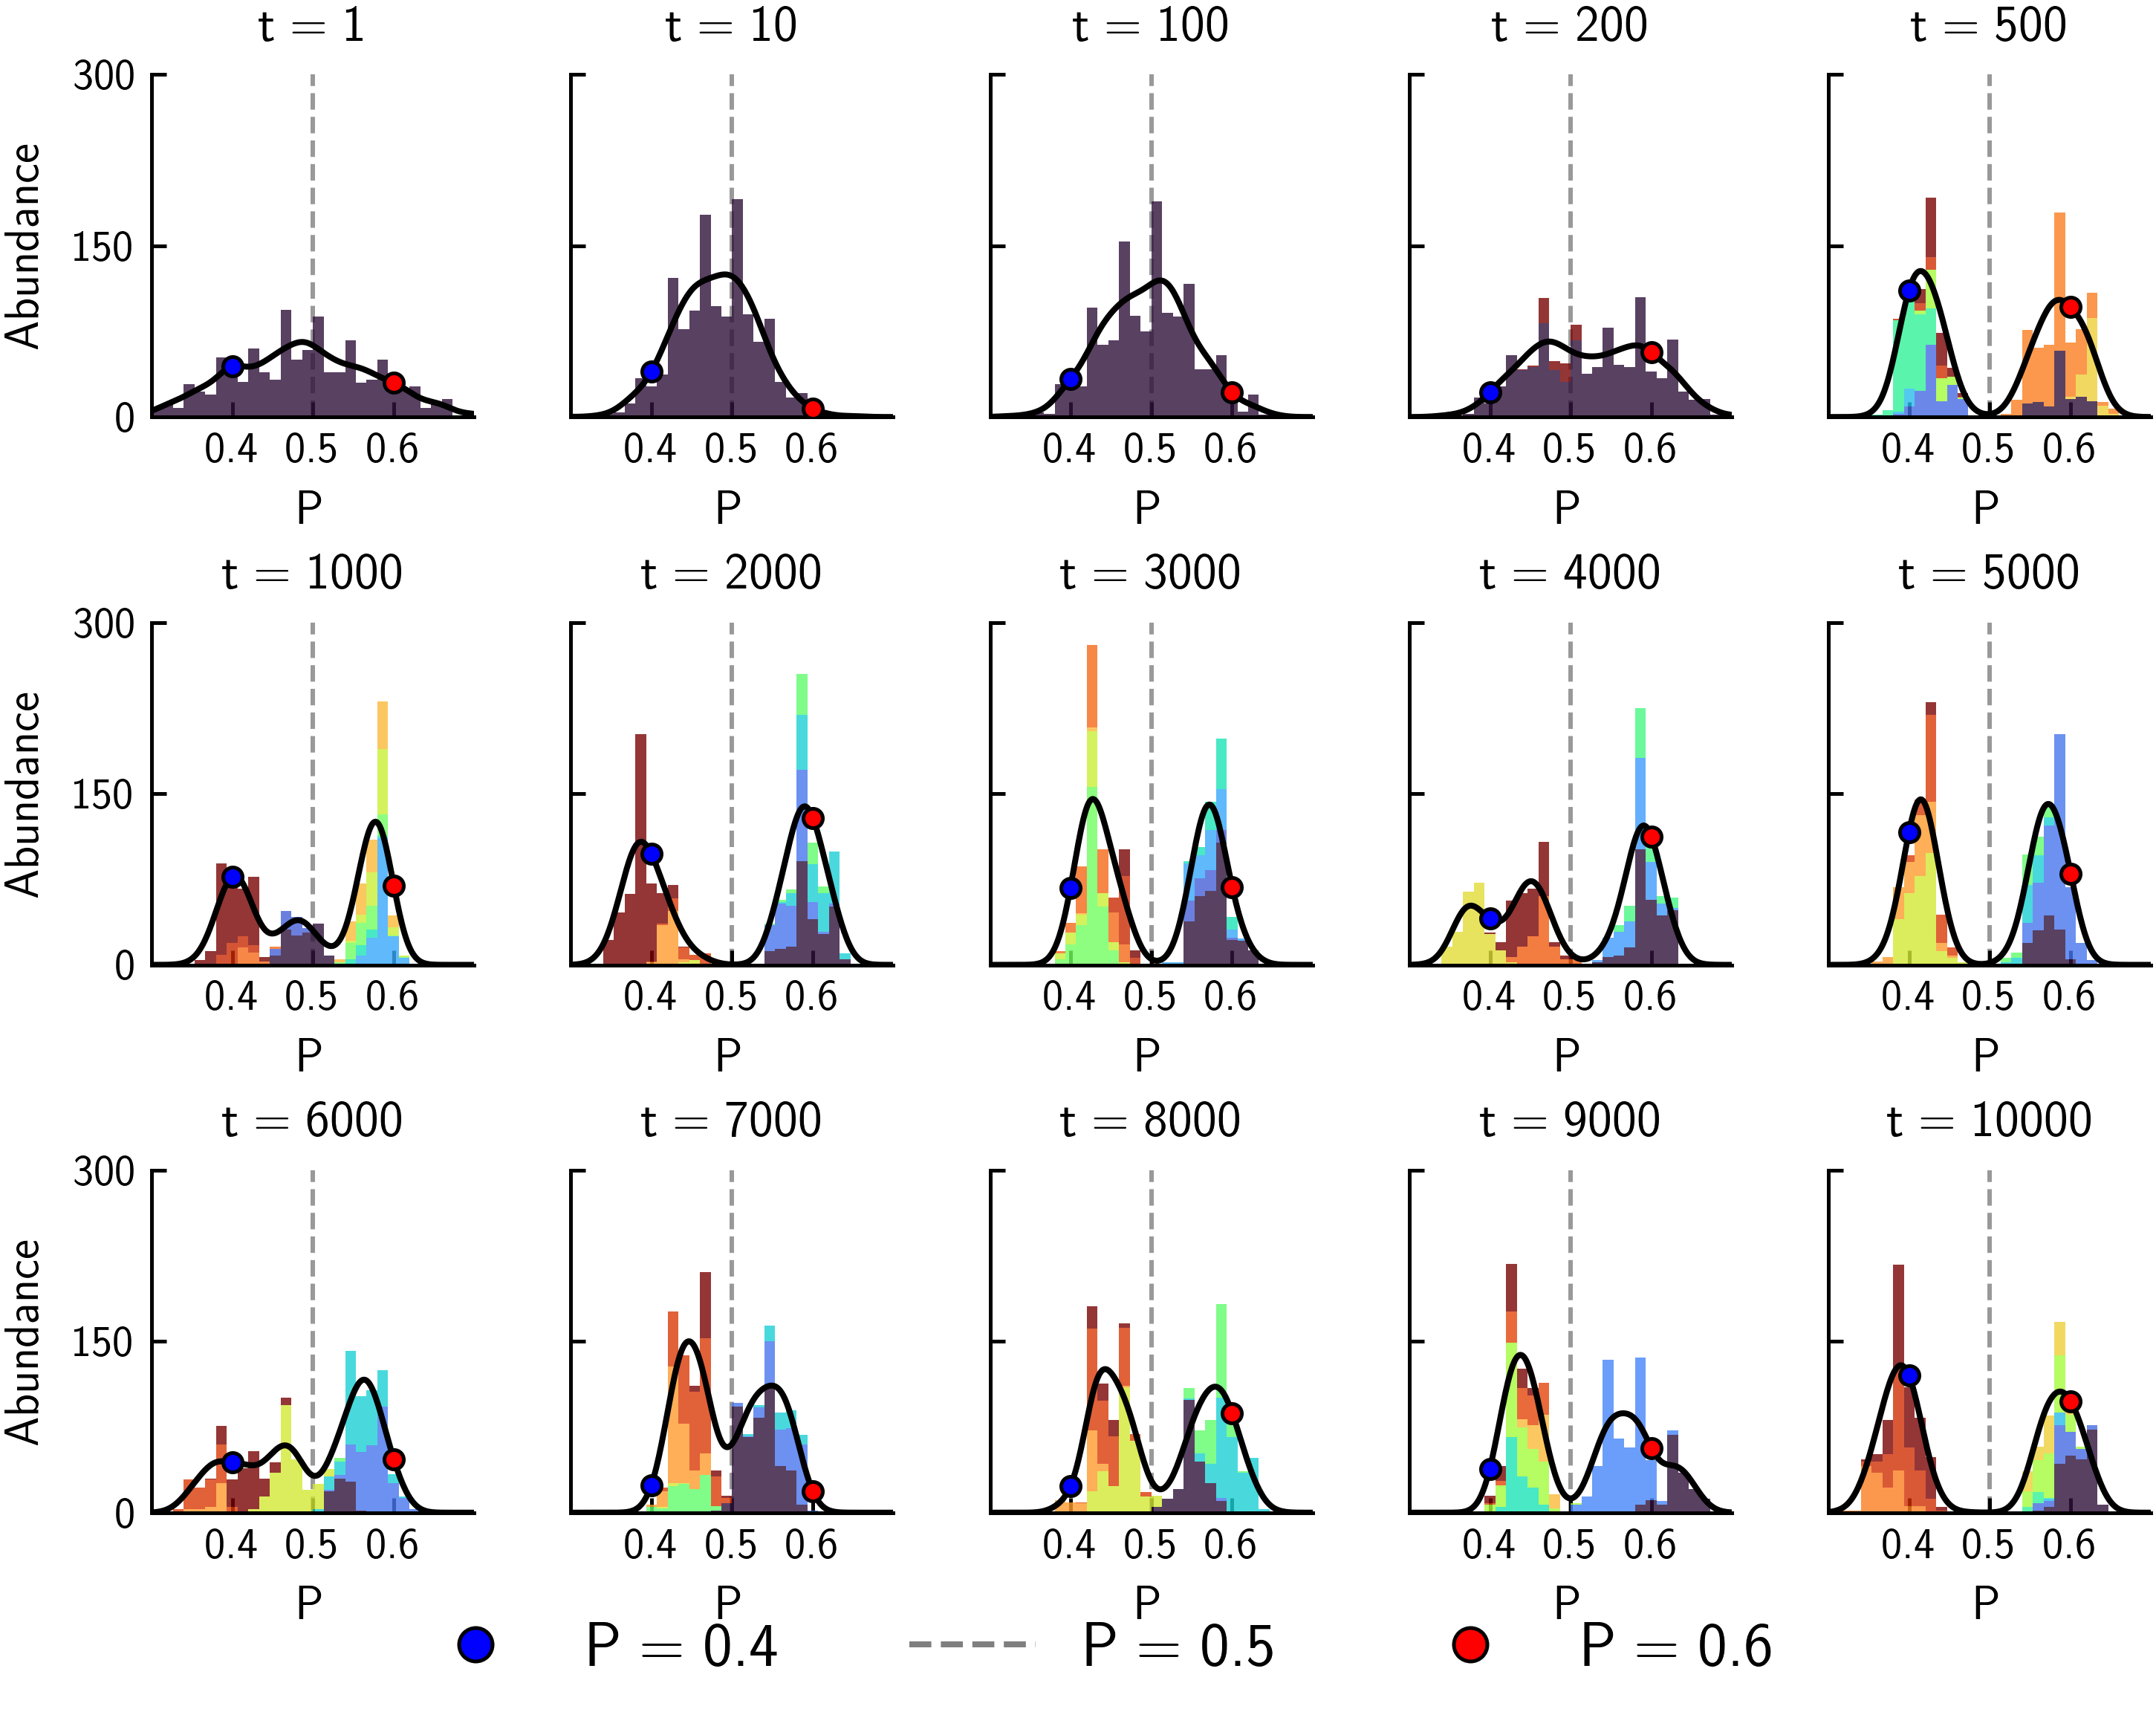

In [10]:
PATH = "DATA/heterogeneous/G5sigma40/All" 
generate_evolution_plot(PATH)